# Delay Analysis and Operational Priorities

## Business objective

This notebook identifies where delivery delays are concentrated and converts the findings into clear operational priorities.

The analysis is performed at the **distinct-order level**. Canceled orders are excluded, and an order is delayed when actual shipping days exceed scheduled shipping days.

## Questions

1. Which shipping modes, markets, regions, and periods combine high delay rates with meaningful order volume?
2. Which shipping modes should be prioritized when both delay severity and affected order volume are considered?
3. How many delayed orders would be avoided under simple 5- and 10-percentage-point improvement scenarios?

> **Interpretation boundary:** the dataset does not contain carrier, warehouse, route, inventory, weather, or process-event data. Results identify observed patterns and operational hypotheses—not proven root causes or causal effects.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.style.use("seaborn-v0_8-whitegrid")

current_path = Path.cwd().resolve()
if (current_path / "data").exists():
    project_root = current_path
elif (current_path.parent / "data").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")

figures_dir = project_root / "docs" / "figures"
processed_dir = project_root / "data" / "processed"
figures_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)


## 1. Load and validate the processed order-item data

Run `01_data_preparation_and_quality.ipynb` first. This notebook deliberately consumes its validated output rather than rebuilding cleaning logic.


In [2]:
data_path = processed_dir / "dataco_cleaned.csv"
if not data_path.exists():
    raise FileNotFoundError(
        f"Processed dataset not found: {data_path}\n"
        "Run 01_data_preparation_and_quality.ipynb first."
    )

df = pd.read_csv(
    data_path,
    low_memory=False,
    parse_dates=["order date (DateOrders)", "shipping date (DateOrders)", "order_date"],
)

required_columns = [
    "Order Id", "Order Item Id", "Order Region", "Market", "Shipping Mode",
    "Order Status", "Sales", "order_date", "is_canceled", "is_delayed",
]
missing = [column for column in required_columns if column not in df.columns]
if missing:
    raise ValueError("Missing required processed columns: " + ", ".join(missing))

print(f"Rows loaded: {len(df):,}")
print(f"Distinct orders: {df['Order Id'].nunique():,}")


Rows loaded: 180,519
Distinct orders: 65,752


## 2. Build one row per order

Shipping mode, market, region, order date, cancellation status, and delay status must be constant within an order before item rows are collapsed. `Order_Value` is summed across items. Product category and department are not forced into a single order-level label because an order may contain multiple values.


In [3]:
order_attributes = [
    "Shipping Mode", "Market", "Order Region", "order_date", "is_canceled", "is_delayed"
]
inconsistent = {
    column: int((df.groupby("Order Id")[column].nunique(dropna=False) > 1).sum())
    for column in order_attributes
}
inconsistent = {column: count for column, count in inconsistent.items() if count}
if inconsistent:
    raise ValueError(f"Order-level attributes vary within an order: {inconsistent}")

orders = (
    df.groupby("Order Id", as_index=False)
      .agg(
          Shipping_Mode=("Shipping Mode", "first"),
          Market=("Market", "first"),
          Order_Region=("Order Region", "first"),
          Order_Date=("order_date", "first"),
          Is_Canceled=("is_canceled", "first"),
          Is_Delayed=("is_delayed", "first"),
          Order_Value=("Sales", "sum"),
          Item_Count=("Order Item Id", "count"),
      )
)
orders["Order_Year"] = orders["Order_Date"].dt.year.astype(str)
orders["Order_Month"] = orders["Order_Date"].dt.month.astype(str).str.zfill(2)

analysis_orders = orders.loc[orders["Is_Canceled"].eq(0)].copy()

assert orders["Order Id"].is_unique
assert analysis_orders["Is_Delayed"].isin([0, 1]).all()
assert len(analysis_orders) == len(orders) - int(orders["Is_Canceled"].sum())

validation = pd.DataFrame({
    "Metric": ["All distinct orders", "Canceled orders", "Analyzed non-canceled orders", "Delayed analyzed orders", "Delay rate (%)"],
    "Value": [
        len(orders), int(orders["Is_Canceled"].sum()), len(analysis_orders),
        int(analysis_orders["Is_Delayed"].sum()), analysis_orders["Is_Delayed"].mean() * 100,
    ],
})
display(validation)


,Metric,Value
0,All distinct orders,"65,752.00"
1,Canceled orders,"2,855.00"
2,Analyzed non-canceled orders,"62,897.00"
3,Delayed analyzed orders,"36,048.00"
4,Delay rate (%),57.31


## 3. Descriptive delay pattern summaries

Rate alone can exaggerate small segments, while volume alone can hide poor reliability. The summaries report both, plus each segment's share of all delayed orders.


In [4]:
def pattern_summary(data, column):
    summary = (
        data.groupby(column, dropna=False)["Is_Delayed"]
            .agg(Orders="size", Delayed_Orders="sum", Delay_Rate="mean")
            .reset_index()
            .rename(columns={column: "Segment"})
    )
    summary.insert(0, "Dimension", column)
    summary["Delay_Rate_Pct"] = summary.pop("Delay_Rate") * 100
    summary["Share_of_All_Delays_Pct"] = (
        summary["Delayed_Orders"] / data["Is_Delayed"].sum() * 100
    )
    return summary.sort_values(["Delayed_Orders", "Orders"], ascending=False)

summary_frames = [
    pattern_summary(analysis_orders, column)
    for column in ["Shipping_Mode", "Market", "Order_Region", "Order_Year", "Order_Month"]
]
pattern_summaries = pd.concat(summary_frames, ignore_index=True)
pattern_summaries.to_csv(processed_dir / "delay_pattern_summary.csv", index=False)

display(pattern_summaries.loc[pattern_summaries["Dimension"].eq("Shipping_Mode")])
display(pattern_summaries.loc[pattern_summaries["Dimension"].eq("Market")])


,Dimension,Segment,Orders,Delayed_Orders,Delay_Rate_Pct,Share_of_All_Delays_Pct
0,Shipping_Mode,Standard Class,37632,14995,39.85,41.60
1,Shipping_Mode,Second Class,12256,9803,79.99,27.19
2,Shipping_Mode,First Class,9602,9602,100.00,26.64
3,Shipping_Mode,Same Day,3407,1648,48.37,4.57


,Dimension,Segment,Orders,Delayed_Orders,Delay_Rate_Pct,Share_of_All_Delays_Pct
4,Market,Europe,17763,10199,57.42,28.29
5,Market,Pacific Asia,16853,9720,57.68,26.96
6,Market,LATAM,16414,9339,56.90,25.91
7,Market,USCA,8178,4704,57.52,13.05
8,Market,Africa,3689,2086,56.55,5.79


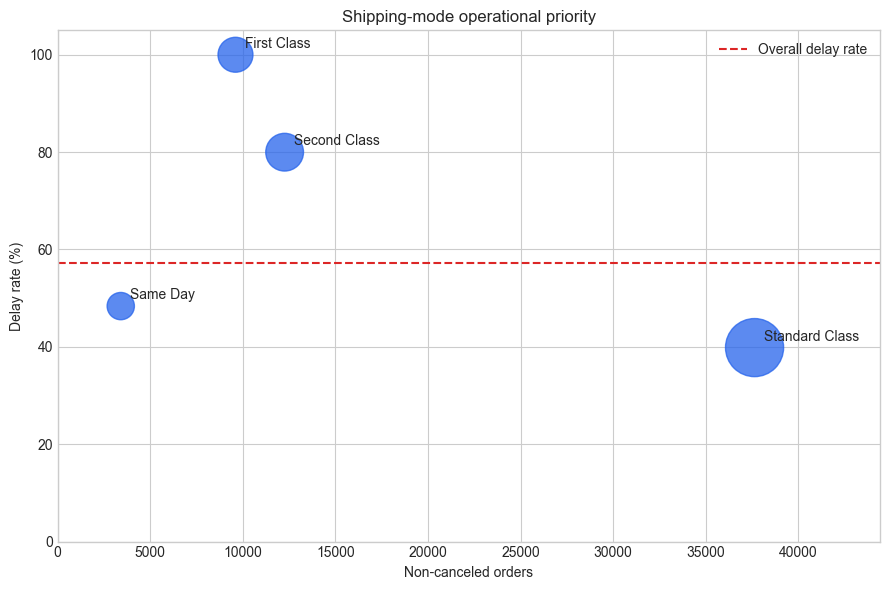

In [5]:
priority = pattern_summaries.loc[pattern_summaries["Dimension"].eq("Shipping_Mode")].copy()

fig, ax = plt.subplots(figsize=(9, 6))
sizes = 250 + 1_500 * priority["Orders"] / priority["Orders"].max()
ax.scatter(priority["Orders"], priority["Delay_Rate_Pct"], s=sizes, color="#2563eb", alpha=0.75)
for _, row in priority.iterrows():
    ax.annotate(row["Segment"], (row["Orders"], row["Delay_Rate_Pct"]), xytext=(7, 5), textcoords="offset points")
ax.axhline(analysis_orders["Is_Delayed"].mean() * 100, color="#dc2626", linestyle="--", label="Overall delay rate")
ax.set(title="Shipping-mode operational priority", xlabel="Non-canceled orders", ylabel="Delay rate (%)", ylim=(0, 105), xlim=(0, priority["Orders"].max() * 1.18))
ax.legend()
plt.tight_layout()
plt.savefig(figures_dir / "delay_priority.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Business impact scenarios

These are transparent planning scenarios—not forecasts. They estimate avoided delayed orders if each shipping mode's historical delay rate were reduced by 5 or 10 percentage points, with order volume held constant. Rates cannot fall below zero.


In [6]:
shipping_summary = pattern_summaries.loc[
    pattern_summaries["Dimension"].eq("Shipping_Mode")
].copy()

scenario_rows = []
for _, row in shipping_summary.iterrows():
    for improvement_pp in (5, 10):
        feasible_reduction_pp = min(float(row["Delay_Rate_Pct"]), improvement_pp)
        avoided_orders = int(round(row["Orders"] * feasible_reduction_pp / 100))
        scenario_rows.append({
            "Shipping_Mode": row["Segment"],
            "Baseline_Orders": int(row["Orders"]),
            "Baseline_Delayed_Orders": int(row["Delayed_Orders"]),
            "Baseline_Delay_Rate_Pct": row["Delay_Rate_Pct"],
            "Improvement_Points": improvement_pp,
            "Estimated_Avoided_Delayed_Orders": avoided_orders,
            "Scenario_Delay_Rate_Pct": max(0, row["Delay_Rate_Pct"] - improvement_pp),
        })

scenarios = pd.DataFrame(scenario_rows).sort_values(
    ["Improvement_Points", "Estimated_Avoided_Delayed_Orders"], ascending=[True, False]
)
scenarios.to_csv(processed_dir / "delay_improvement_scenarios.csv", index=False)
display(scenarios)


,Shipping_Mode,Baseline_Orders,Baseline_Delayed_Orders,Baseline_Delay_Rate_Pct,Improvement_Points,Estimated_Avoided_Delayed_Orders,Scenario_Delay_Rate_Pct
0,Standard Class,37632,14995,39.85,5,1882,34.85
2,Second Class,12256,9803,79.99,5,613,74.99
4,First Class,9602,9602,100.00,5,480,95.00
6,Same Day,3407,1648,48.37,5,170,43.37
1,Standard Class,37632,14995,39.85,10,3763,29.85
3,Second Class,12256,9803,79.99,10,1226,69.99
5,First Class,9602,9602,100.00,10,960,90.00
7,Same Day,3407,1648,48.37,10,341,38.37


## 5. Decision summary and next-data request

The descriptive priority table shows where operational investigation should begin. First Class requires immediate review because its observed delay rate is 100%, while Standard Class deserves high priority because its large order volume produces the greatest number of delayed orders.

The scenario table translates a selected improvement target into an estimated number of avoided delayed orders. It is a planning estimate based on historical volume, not a forecast or causal claim.

Recommended next step inside a real company: collect and join carrier, warehouse, route and distance, inventory availability, promised timestamp, pick-and-pack completion, carrier handoff, weather, exception-reason, and delay-cost data. These fields are needed to test root-cause hypotheses and estimate the financial impact of delays more accurately.
